<div style="background-color: #d1ecf1; color: #0c5460; padding: 10px; border-radius: 5px; font-weight: bold; font-size: 18px;"><h3><align = "center">
  TASK 07 : Explainable AI Analysis
</div></h3>

# 1. Install and Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

shap.initjs()

# 2. Load Best Model and Data

In [4]:
# Mount google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
SAVE_DIR = "/content/drive/MyDrive/AI_Coursework/models"

split_data = joblib.load(f"{SAVE_DIR}/train_test_split.joblib")
X_train = split_data["X_train"]
X_test  = split_data["X_test"]
y_test  = split_data["y_test"]

best_model_name = "Logistic Regression"

best_model = joblib.load(f"{SAVE_DIR}/logistic_regression.joblib")

print(f"Explaining model: {best_model_name}")
print("X_test shape:", X_test.shape)

Explaining model: Logistic Regression
X_test shape: (200, 29)


# 3. Create the SHAP Explainer

In [10]:
masker = shap.maskers.Independent(X_train, max_samples=X_train.shape[0])
explainer = shap.Explainer(best_model.predict_proba, masker)
shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.values.shape)

PermutationExplainer explainer: 201it [00:36,  4.16it/s]

SHAP values shape: (200, 29, 2)


# 4. Global Feature Importance (Summary Plot)

<Figure size 640x480 with 0 Axes>

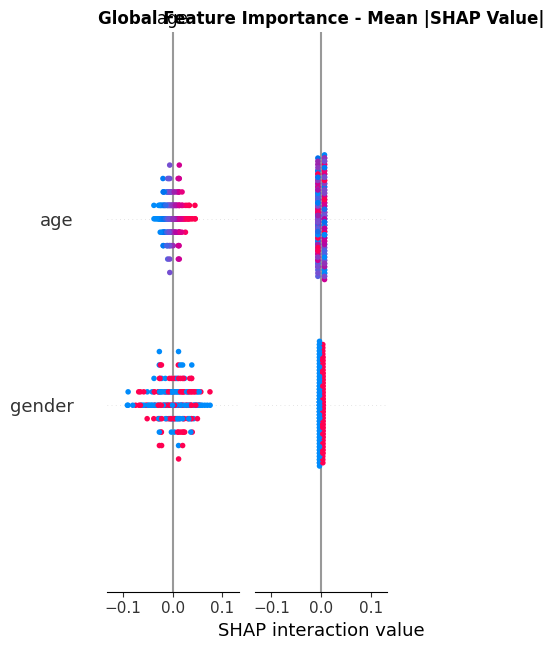

In [11]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Global Feature Importance - Mean |SHAP Value|", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_bar_summary.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

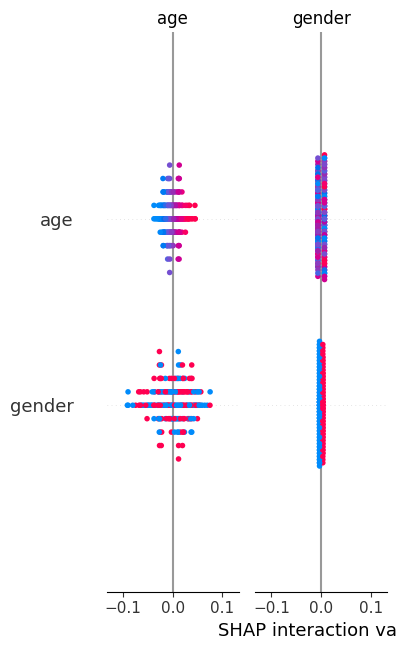

In [12]:
#Beeswarm Plot
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_beeswarm_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Local Explanation - Individual Prediction

In [13]:
sample_idx = 0

plt.figure()
shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.tight_layout()
plt.savefig("shap_waterfall_sample.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Actual label for this patient: {'No-Show' if y_test.iloc[sample_idx]==1 else 'Attended'}")
print(f"Predicted label: {'No-Show' if best_model.predict(X_test.iloc[[sample_idx]])[0]==1 else 'Attended'}")

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (29, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

<Figure size 640x480 with 0 Axes>

# 6. Cross-Check with Model Coeffficient

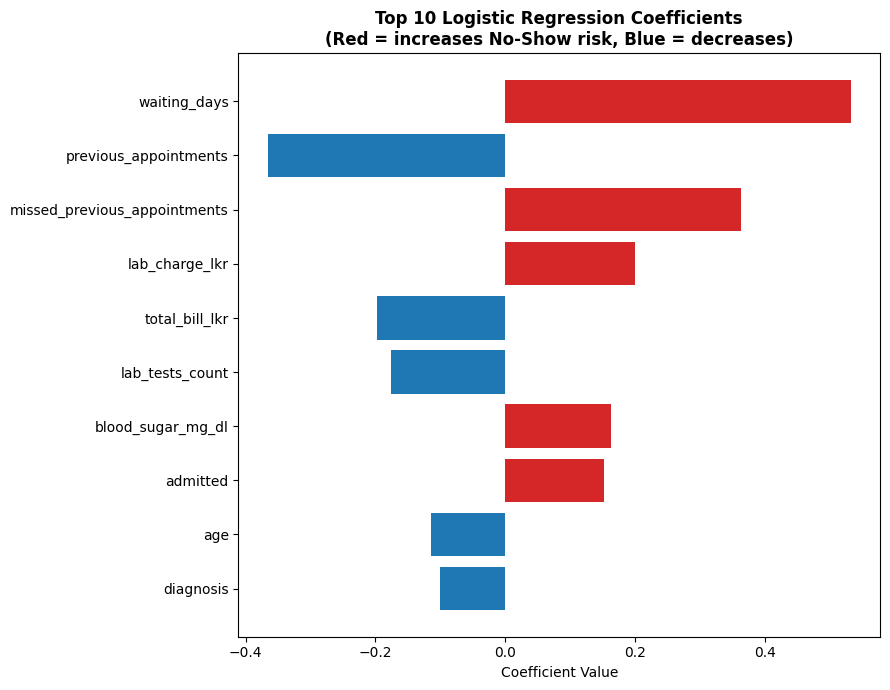

,Feature,Coefficient
0,waiting_days,0.532057
1,previous_appointments,-0.365993
2,missed_previous_appointments,0.362236
3,lab_charge_lkr,0.199285
4,total_bill_lkr,-0.198310
5,lab_tests_count,-0.176697
6,blood_sugar_mg_dl,0.162368
7,admitted,0.151230
8,age,-0.115064
9,diagnosis,-0.101134


In [ ]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": best_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 7))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in coef_df["Coefficient"][:10]]
plt.barh(coef_df["Feature"][:10][::-1], coef_df["Coefficient"][:10][::-1], color=colors[::-1])
plt.title("Top 10 Logistic Regression Coefficients\n(Red = increases No-Show risk, Blue = decreases)", fontweight="bold")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

coef_df.head(10)

# 8. Save Explainability Outputs



In [ ]:
coef_df.to_csv(f"{SAVE_DIR}/shap_feature_importance.csv", index=False)
print(f"Saved: {SAVE_DIR}/shap_feature_importance.csv")

## 6. Comprehensive Explainable AI (XAI) Analysis & Discussion

### A. Global Feature Importance Insights (SHAP Summary & Beeswarm Plots)
- **`waiting_days`**: This is the most influential feature driving the model's predictions. Patients with a longer gap between booking and the appointment date show a significantly higher likelihood of a No-Show.
- **Previous Attendance Behavior (`previous_appointments` & `missed_previous_appointments`)**:
  - A higher number of `previous_appointments` strongly pulls the prediction towards "Attended".
  - Conversely, a high count of `missed_previous_appointments` increases the predicted probability of a "No-Show".
- **Financial & Clinical Indicators**: Features such as `lab_charge_lkr`, `total_bill_lkr`, and `blood_sugar_mg_dl` also contribute moderately to the prediction outcome.

### B. Local Feature Explanation (Waterfall Plot)
- The Waterfall plot illustrates the decision path for an individual patient instance.
- It calculates the base value $E[f(X)]$ (the average model outcome across the dataset) and adds/subtracts individual feature contributions ($\phi_i$) to reach the final probability output $f(x)$.
- This enables doctors and administrators to understand **why** a specific patient was flagged as high-risk for a No-Show.

### C. Transparency & Ethical Implications
1. **Model Transparency**: Black-box machine learning models can lead to distrust in clinical settings. Using SHAP values provides clear explainability, allowing hospital administrators to justify operational interventions (e.g., sending targeted SMS reminders).
2. **Fairness & Bias**: Demographic attributes like `age` and `gender` are monitored via SHAP to ensure the model does not unfairly discriminate or penalize specific patient subgroups.
3. **Human-in-the-Loop**: The AI system acts as a decision support tool. Clinical and administrative actions should always involve human oversight rather than automated care denial.